# 01 - Data Exploration

Explore the Group 5 ACORN segments, historical consumption, weather relationships, and temporal patterns.

In [18]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from group5_energy.config import ACORN_GROUPS
from group5_energy.pipeline import load_daily_history, load_half_hourly_history, load_daily_weather

sns.set_theme(style="whitegrid")

In [19]:
daily = load_daily_history()
half = load_half_hourly_history()
weather = load_daily_weather()

print("Daily rows:", daily.shape)
print("Half-hourly rows:", half.shape)
print("ACORN groups:", ACORN_GROUPS)
print("Daily date range:", daily["Date"].min(), "to", daily["Date"].max())
print("Half-hourly date range:", half["DateTime"].min(), "to", half["DateTime"].max())

Daily rows: (1683, 5)
Half-hourly rows: (80796, 6)
ACORN groups: {'ACORN-E': 'Affluent', 'ACORN-F': 'Comfortable', 'ACORN-Q': 'Adversity'}
Daily date range: 2012-07-01 00:00:00 to 2014-01-12 00:00:00
Half-hourly date range: 2012-06-30 22:00:00 to 2014-01-12 23:30:00


In [20]:
daily.groupby("Acorn")["Conso_kWh"].agg(["count", "mean", "min", "max"]).round(3)

,count,mean,min,max
Acorn,,,,
ACORN-E,561,10.248,7.087,16.050
ACORN-F,561,9.207,7.147,13.495
ACORN-Q,561,7.515,6.118,10.350


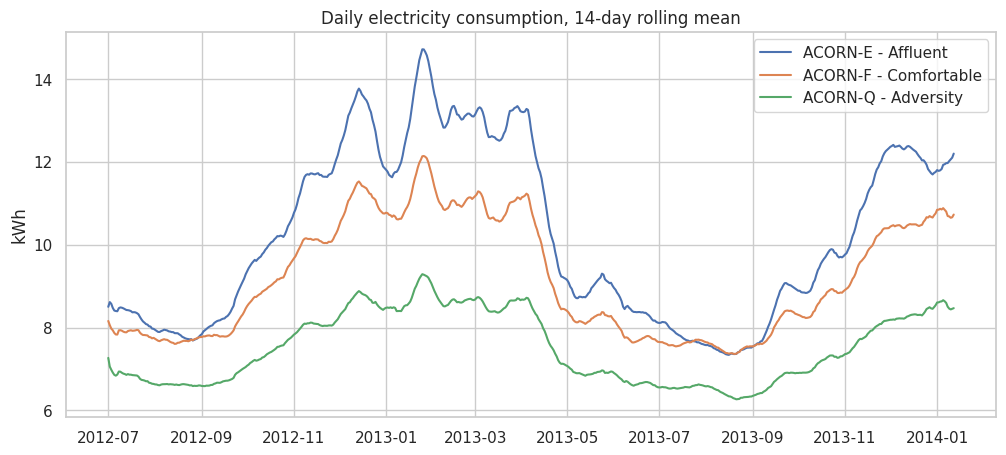

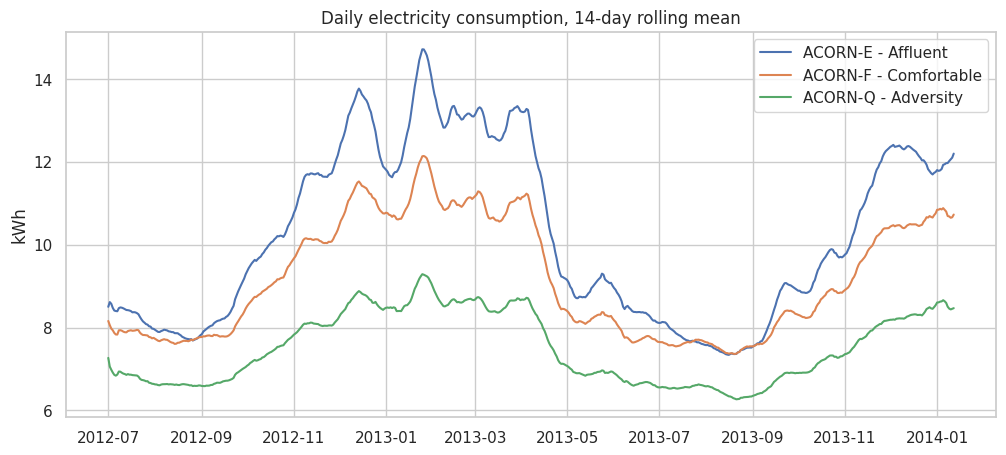

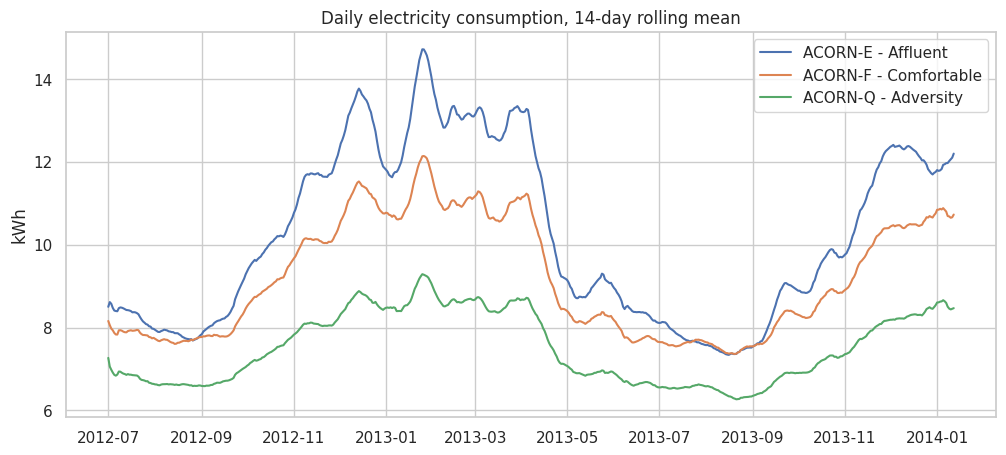

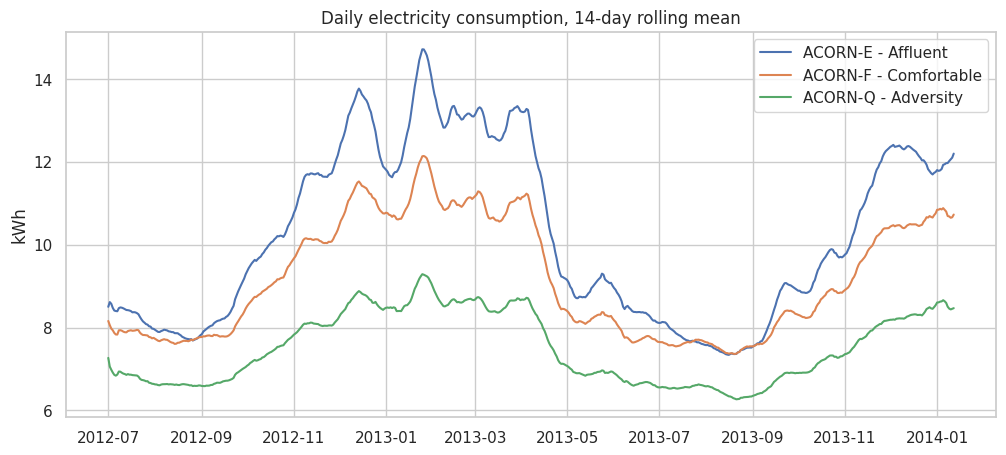

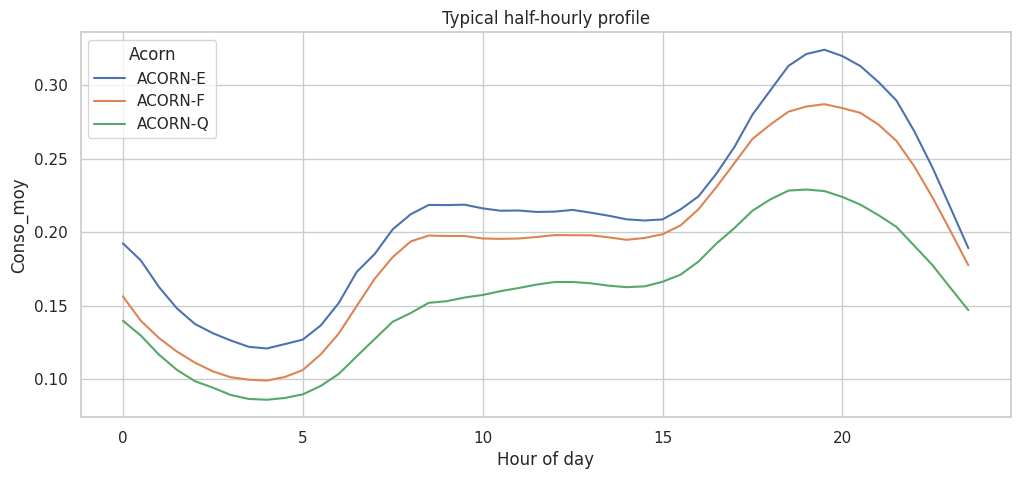

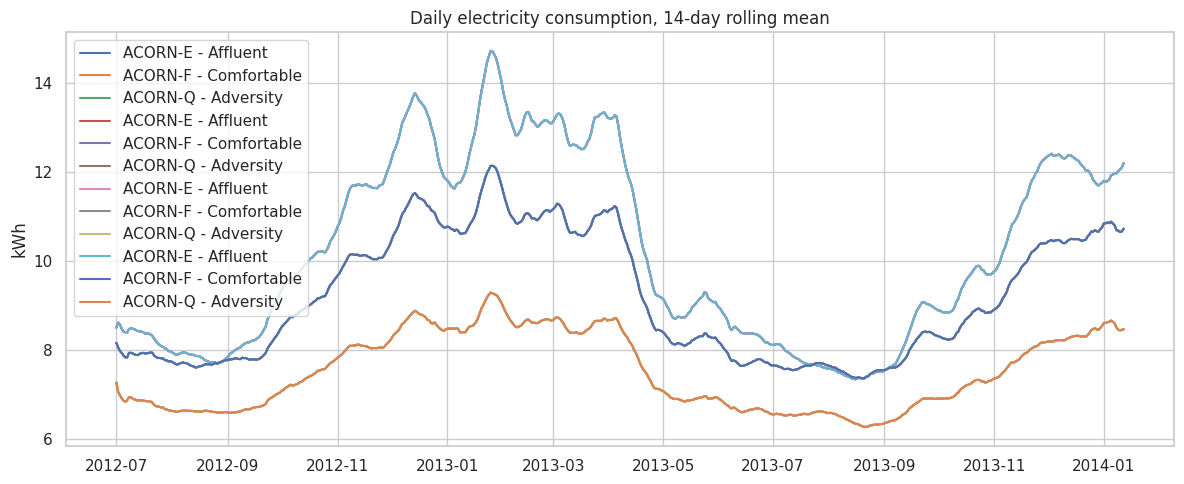

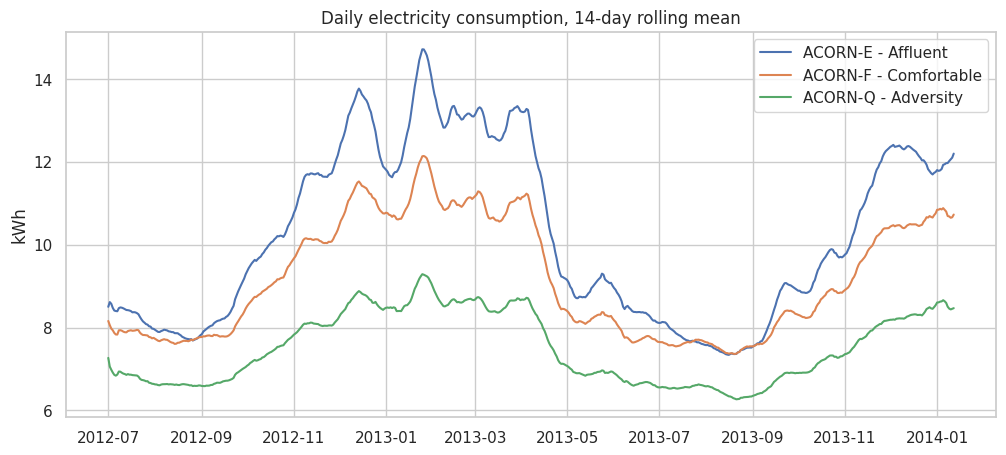

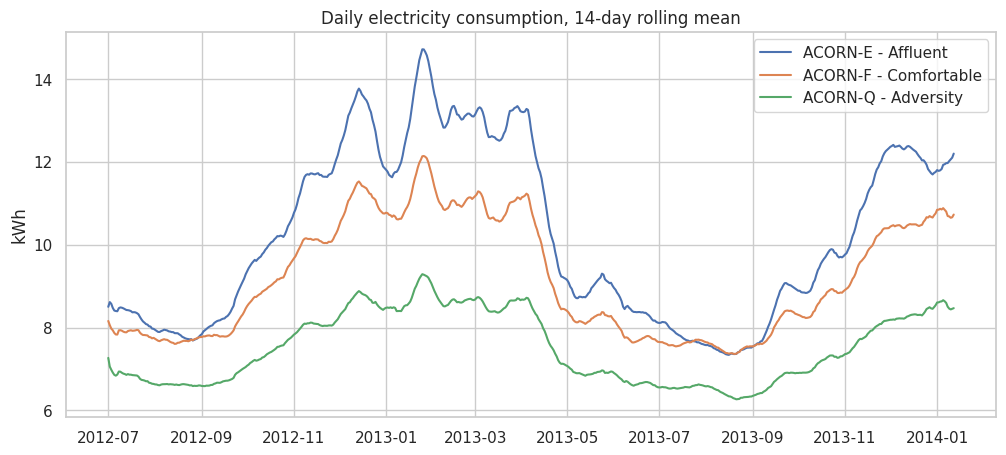

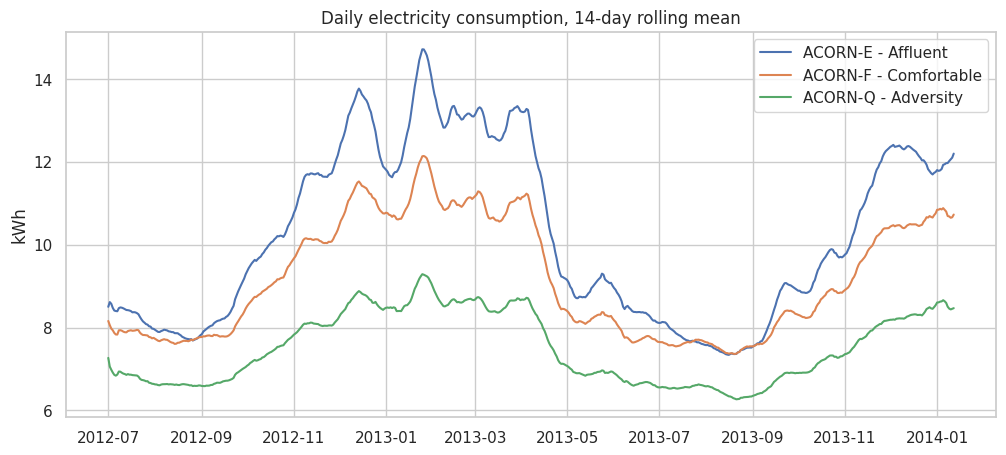

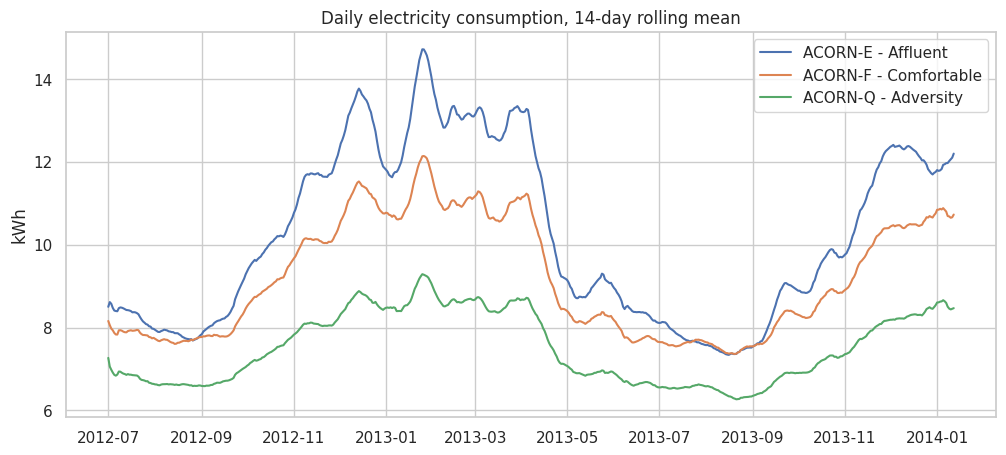

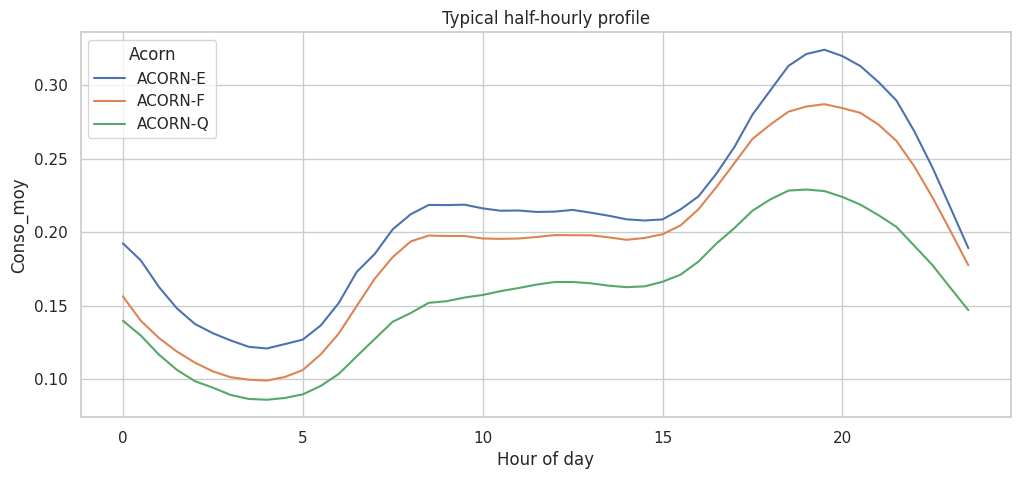

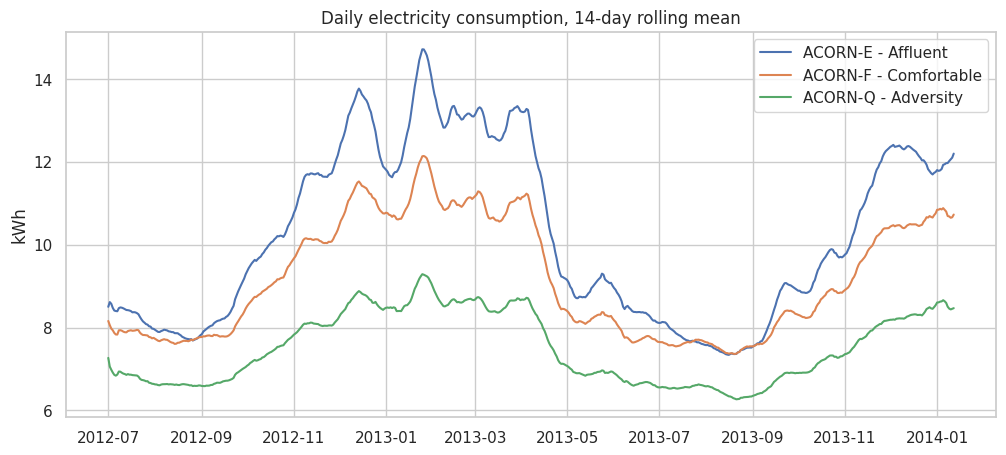

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
for acorn, group in daily.sort_values("Date").groupby("Acorn"):
    rolling = group.set_index("Date")["Conso_kWh"].rolling(14, min_periods=1).mean()
    ax.plot(rolling.index, rolling.values, label=f"{acorn} - {ACORN_GROUPS[acorn]}")
ax.set_title("Daily electricity consumption, 14-day rolling mean")
ax.set_ylabel("kWh")
ax.legend()
plt.show()

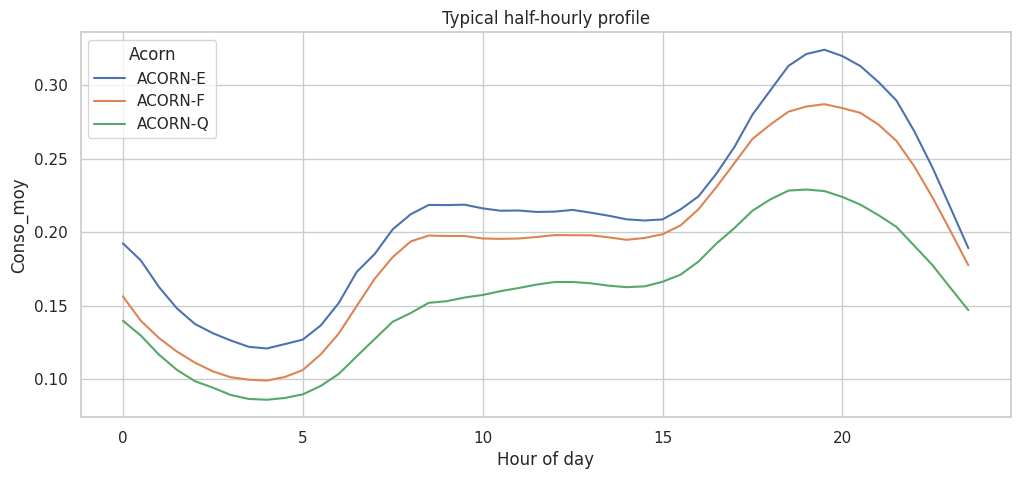

In [22]:
profile = half.copy()
profile["half_hour_slot"] = profile["DateTime"].dt.hour * 2 + (profile["DateTime"].dt.minute // 30)
profile = profile.groupby(["Acorn", "half_hour_slot"], as_index=False)["Conso_moy"].mean()
profile["time_of_day"] = profile["half_hour_slot"] / 2

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=profile, x="time_of_day", y="Conso_moy", hue="Acorn", ax=ax)
ax.set_title("Typical half-hourly profile")
ax.set_xlabel("Hour of day")
plt.show()

In [23]:
daily_weather = daily.merge(weather[["Date", "temperatureMean"]], on="Date", how="left")
daily_weather.groupby("Acorn").apply(
    lambda group: group["Conso_kWh"].corr(group["temperatureMean"]),
    include_groups=False,
).rename("temperature_consumption_corr").round(3)

Acorn
ACORN-E   -0.917
ACORN-F   -0.885
ACORN-Q   -0.868
Name: temperature_consumption_corr, dtype: float64